# PRAGMA-lite masked-transaction training

This notebook trains the current end-to-end model: **Event Encoder → Profile Encoder → History Encoder → masked-field MLM head**. It uses the account-disjoint train/validation parquet splits created in the exploration notebook.

## Before running in a Colab runtime

The VS Code Colab extension runs code on a remote Colab machine; it cannot see this Windows folder by itself. The recommended setup is to put the project on the Colab VM's fast, temporary `/content` disk, not to train from mounted Drive. The setup cell can clone a public Git repository, or you can upload one project zip directly from your laptop.

- `finBERTlitemodules/`
- `data/processed/czech_bank/`
- `financial_db_Teradata/`

The project material needed for this experiment is about 71 MiB, so a direct zip upload is perfectly reasonable. It does **not** consume Google Drive storage, but it must be repeated after the Colab VM resets. In Colab, select a GPU runtime before you run the notebook. The configuration cell is the one place to change batch size, epochs, or a resume checkpoint.

In [2]:
# Install the one dependency Colab may not already have. This installs
# into the current temporary VM, not into Google Drive.
%pip install -q pyarrow scikit-learn

import shutil
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
PROJECT_ROOT = Path('/content/FinancialBertForTransactions') if IN_COLAB else Path.cwd()

# OPTION A — recommended after you push this repository to GitHub. Set the
# URL once, then the code is cloned onto the Colab VM at each new session.
REPOSITORY_URL = 'https://github.com/Extraterrestrial-T/FinancialBertForTransactions'  # e.g. 'https://github.com/YOUR_USERNAME/FinancialBertForTransactions.git'
if IN_COLAB and REPOSITORY_URL and not PROJECT_ROOT.exists():
    !git clone --depth=1 {REPOSITORY_URL} {PROJECT_ROOT}

# OPTION B — no Drive and no GitHub needed. First zip this project on your
# laptop, then change this to True and choose that zip in the upload dialog.
# The zip must unpack to /content/FinancialBertForTransactions/.
UPLOAD_PROJECT_ZIP = False
if IN_COLAB and UPLOAD_PROJECT_ZIP and not PROJECT_ROOT.exists():
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError('Choose exactly one project zip archive.')
    archive_path = Path(next(iter(uploaded)))
    shutil.unpack_archive(archive_path, '/content')

PROJECT_ROOT = PROJECT_ROOT.resolve()
assert (PROJECT_ROOT / 'finBERTlitemodules').exists(), (
    f'Cannot find the project at {PROJECT_ROOT}. Use Option A or Option B above.'
)
# This makes `from finBERTlitemodules import ...` work exactly as it does
# locally: Python looks for packages relative to the project root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'Running in Colab: {IN_COLAB}')
if IN_COLAB:
    !nvidia-smi

Cloning into '/content/FinancialBertForTransactions'...
remote: Enumerating objects: 458, done.
remote: Counting objects: 100% (458/458), done.
remote: Compressing objects: 100% (446/446), done.
remote: Total 458 (delta 7), reused 458 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (458/458), 616.71 MiB | 20.03 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Updating files: 100% (441/441), done.
Project root: /content/FinancialBertForTransactions
Running in Colab: True
Mon Aug 10 20:26:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                      

## Persistent checkpoints in Google Drive

The model, data, and training batches remain on the fast `/content` disk. This cell mounts Drive only for small persistent artifacts: `best.pt`, `last.pt`, tokenizer states, and `metrics.csv`.

In [5]:
# Keep training I/O on /content, but preserve restartable artifacts in Drive.
PERSIST_CHECKPOINTS_TO_DRIVE = True

if IN_COLAB and PERSIST_CHECKPOINTS_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    ARTIFACT_ROOT = Path('/content/drive/MyDrive/FinancialBertForTransactions')
else:
    ARTIFACT_ROOT = PROJECT_ROOT

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Persistent artifacts: {ARTIFACT_ROOT}')

Mounted at /content/drive
Persistent artifacts: /content/drive/MyDrive/FinancialBertForTransactions


## Imports and configuration

The split is by `account_id`, not transaction row. Tokenizer boundaries are fitted **only** from the train split and then reused for validation. `MAX_EVENTS` is the history context window; events before that window are excluded from the current sample.

In [6]:
from dataclasses import asdict
from time import perf_counter

import pandas as pd
import torch
from torch import Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader

from finBERTlitemodules import (
    EventMLMDemoModel,
    FinBERTLiteCzechDataset,
    TransformerConfig,
    apply_value_mlm_mask,
    collate_account_records,
    fit_tokenizer_bundle,
    save_tokenizer_bundle,
)

SEED = 42
EPOCHS = 300
BATCH_SIZE = 128         # Start here on a Colab T4/L4; increase only after one epoch works.
MAX_EVENTS = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# Set to e.g. CHECKPOINT_DIR / 'last.pt' to continue an interrupted run.
RESUME_FROM = None

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'czech_bank'
SOURCE_DIR = PROJECT_ROOT / 'financial_db_Teradata'
CHECKPOINT_DIR = ARTIFACT_ROOT / 'checkpoints' / 'pragma_lite_mlm'
TOKENIZER_DIR = CHECKPOINT_DIR / 'tokenizers'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_EVENTS = DATA_DIR / 'events_train.parquet'
TRAIN_PROFILES = DATA_DIR / 'profile_train.parquet'
VALID_EVENTS = DATA_DIR / 'events_valid.parquet'
VALID_PROFILES = DATA_DIR / 'profile_valid.parquet'
for required_path in (TRAIN_EVENTS, TRAIN_PROFILES, VALID_EVENTS, VALID_PROFILES, SOURCE_DIR):
    assert required_path.exists(), f'Missing required path: {required_path}'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}; mixed precision: {AMP_ENABLED}')

Device: cuda; mixed precision: True


## Fit the train-only tokenizer bundle and build datasets

This happens once at the beginning of a fresh run. The resulting tokenizer states are saved with the checkpoint so validation and a future resumed run use identical numeric bucket boundaries.

In [7]:
# `fit_tokenizer_bundle` may take a moment because it reads the train split
# and the lifetime source tables. It never reads validation data to fit bins.
train_events_frame = pd.read_parquet(TRAIN_EVENTS)
train_profiles_frame = pd.read_parquet(TRAIN_PROFILES)
tokenizers = fit_tokenizer_bundle(train_events_frame, train_profiles_frame, SOURCE_DIR)
save_tokenizer_bundle(tokenizers, TOKENIZER_DIR)
vocabulary_size = len(tokenizers.event.token_to_id)
del train_events_frame, train_profiles_frame

train_dataset = FinBERTLiteCzechDataset(
    TRAIN_EVENTS, TRAIN_PROFILES, SOURCE_DIR, tokenizers,
    max_events=MAX_EVENTS, random_cutoff=True, seed=SEED,
)
valid_dataset = FinBERTLiteCzechDataset(
    VALID_EVENTS, VALID_PROFILES, SOURCE_DIR, tokenizers,
    max_events=MAX_EVENTS, random_cutoff=False, seed=SEED,
)

loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type == 'cuda',
    'collate_fn': collate_account_records,
}
train_loader = DataLoader(
    train_dataset, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)

print(f'Train accounts: {len(train_dataset):,}')
print(f'Valid accounts: {len(valid_dataset):,}')
print(f'Vocabulary size: {vocabulary_size}')
print(f'Train batches/epoch: {len(train_loader):,}')

Train accounts: 3,138
Valid accounts: 672
Vocabulary size: 113
Train batches/epoch: 25


## Create the model and the training helpers

The MLM labels are the original values at selected field positions; all other labels are `-100` and are ignored by cross-entropy. The event keys remain visible, so the prediction head knows which field's candidate distribution it is modelling.

In [8]:
MODEL_CONFIG = TransformerConfig(
    d_model=128,
    num_heads=8,
    num_layers=2,
    ffn_dim=256,
    dropout=0.1,
)
model = EventMLMDemoModel(vocabulary_size, MODEL_CONFIG).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=AMP_ENABLED)

def move_tensors(batch: dict[str, object]) -> dict[str, object]:
    return {
        name: value.to(DEVICE, non_blocking=True) if isinstance(value, Tensor) else value
        for name, value in batch.items()
    }

def forward_from_batch(masked_batch: dict[str, object]):
    return model(
        masked_batch['event_key_ids'],
        masked_batch['event_value_ids'],
        masked_batch['event_mask'],
        masked_batch['profile_key_ids'],
        masked_batch['profile_value_ids'],
        masked_batch['profile_mask'],
        masked_batch['profile_rope_time'],
        masked_batch['history_rope_time'],
        masked_batch['calendar_features'],
    )

def mlm_cross_entropy(logits: Tensor, labels: Tensor) -> Tensor:
    return F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        labels.reshape(-1),
        ignore_index=-100,
    )

def make_mask_generator(seed: int) -> torch.Generator:
    # `apply_value_mlm_mask` samples directly on the batch's device.
    return torch.Generator(device=DEVICE.type).manual_seed(seed)

print(f'Model parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')

Model parameters: 868,081


## Optional: resume an interrupted run

Set `RESUME_FROM = CHECKPOINT_DIR / 'last.pt'` in the configuration cell, then run this cell before training. The same tokenizer state saved in `TOKENIZER_DIR` should accompany the checkpoint.

In [9]:
start_epoch = 1
best_validation_loss = float('inf')
if RESUME_FROM is not None:
    checkpoint = torch.load(RESUME_FROM, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = int(checkpoint['epoch']) + 1
    best_validation_loss = float(checkpoint['best_validation_loss'])
    print(f'Resumed after epoch {start_epoch - 1}; best validation loss={best_validation_loss:.4f}')
else:
    print('Starting a fresh run.')

Starting a fresh run.


## Train and validate

Every training epoch uses deterministic but different random cutoff days through `train_dataset.set_epoch(epoch)`. Validation always uses each account's final cutoff day. The validation mask is reset to a fixed seed each epoch, so its loss is comparable over time.

In [10]:
history: list[dict[str, float]] = []
train_mask_generator = make_mask_generator(SEED + 100)

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = perf_counter()
    train_dataset.set_epoch(epoch)
    model.train()
    train_loss_sum = 0.0
    train_target_count = 0

    for raw_batch in train_loader:
        batch = move_tensors(raw_batch)
        masked_batch = apply_value_mlm_mask(batch, generator=train_mask_generator)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            output = forward_from_batch(masked_batch)
            loss = mlm_cross_entropy(output.logits, masked_batch['mlm_labels'])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        target_count = int(masked_batch['mlm_mask'].sum().item())
        train_loss_sum += loss.item() * target_count
        train_target_count += target_count

    model.eval()
    valid_loss_sum = 0.0
    valid_target_count = 0
    valid_mask_generator = make_mask_generator(SEED + 200)
    with torch.no_grad():
        for raw_batch in valid_loader:
            batch = move_tensors(raw_batch)
            masked_batch = apply_value_mlm_mask(batch, generator=valid_mask_generator)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                output = forward_from_batch(masked_batch)
                loss = mlm_cross_entropy(output.logits, masked_batch['mlm_labels'])
            target_count = int(masked_batch['mlm_mask'].sum().item())
            valid_loss_sum += loss.item() * target_count
            valid_target_count += target_count

    if train_target_count == 0 or valid_target_count == 0:
        raise RuntimeError('No MLM targets were selected; check masking probabilities.')
    train_loss = train_loss_sum / train_target_count
    valid_loss = valid_loss_sum / valid_target_count
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed_seconds = perf_counter() - epoch_start

    epoch_record = {
        'epoch': float(epoch),
        'train_loss': train_loss,
        'validation_loss': valid_loss,
        'learning_rate': current_lr,
        'seconds': elapsed_seconds,
    }
    history.append(epoch_record)
    print(
        f"epoch {epoch:>2}/{EPOCHS}: train={train_loss:.4f}, valid={valid_loss:.4f}, "
        f"lr={current_lr:.2e}, time={elapsed_seconds:.1f}s"
    )

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_validation_loss': min(best_validation_loss, valid_loss),
        'model_config': asdict(MODEL_CONFIG),
        'vocabulary_size': vocabulary_size,
        'max_events': MAX_EVENTS,
    }
    torch.save(checkpoint, CHECKPOINT_DIR / 'last.pt')
    if valid_loss < best_validation_loss:
        best_validation_loss = valid_loss
        torch.save(checkpoint, CHECKPOINT_DIR / 'best.pt')
        print('  saved new best.pt')

metrics = pd.DataFrame(history)
metrics.to_csv(CHECKPOINT_DIR / 'metrics.csv', index=False)
metrics

epoch  1/300: train=3.3589, valid=2.2702, lr=3.00e-04, time=11.2s
  saved new best.pt
epoch  2/300: train=1.9993, valid=1.7132, lr=3.00e-04, time=9.7s
  saved new best.pt
epoch  3/300: train=1.7269, valid=1.6039, lr=3.00e-04, time=8.8s
  saved new best.pt
epoch  4/300: train=1.6515, valid=1.5622, lr=3.00e-04, time=9.6s
  saved new best.pt
epoch  5/300: train=1.5719, valid=1.5198, lr=3.00e-04, time=8.4s
  saved new best.pt
epoch  6/300: train=1.5355, valid=1.4601, lr=3.00e-04, time=9.4s
  saved new best.pt
epoch  7/300: train=1.5039, valid=1.4328, lr=3.00e-04, time=8.7s
  saved new best.pt
epoch  8/300: train=1.4691, valid=1.4086, lr=3.00e-04, time=8.2s
  saved new best.pt
epoch 10/300: train=1.4510, valid=1.3646, lr=2.99e-04, time=8.9s
  saved new best.pt
epoch 11/300: train=1.4157, valid=1.3373, lr=2.99e-04, time=8.4s
  saved new best.pt
epoch 12/300: train=1.3889, valid=1.3200, lr=2.99e-04, time=8.6s
  saved new best.pt
epoch 13/300: train=1.3608, valid=1.2921, lr=2.99e-04, time=9.2s

,epoch,train_loss,validation_loss,learning_rate,seconds
0,1.0,3.358855,2.270187,3.000000e-04,11.201185
1,2.0,1.999302,1.713204,2.999918e-04,9.735583
2,3.0,1.726924,1.603942,2.999671e-04,8.812270
3,4.0,1.651471,1.562180,2.999260e-04,9.559960
4,5.0,1.571889,1.519815,2.998684e-04,8.390950
...,...,...,...,...,...
295,296.0,0.840241,0.746750,2.055698e-07,8.203942
296,297.0,0.844220,0.746744,1.315755e-07,9.289598
297,298.0,0.842732,0.746745,7.401595e-08,8.718970
298,299.0,0.845358,0.746728,3.289748e-08,8.351809


## Inspect the learning curve and saved artifacts

MLM loss should fall meaningfully from its initial value. Do not treat it as a downstream credit-risk or recommendation metric; this is representation pre-training only.

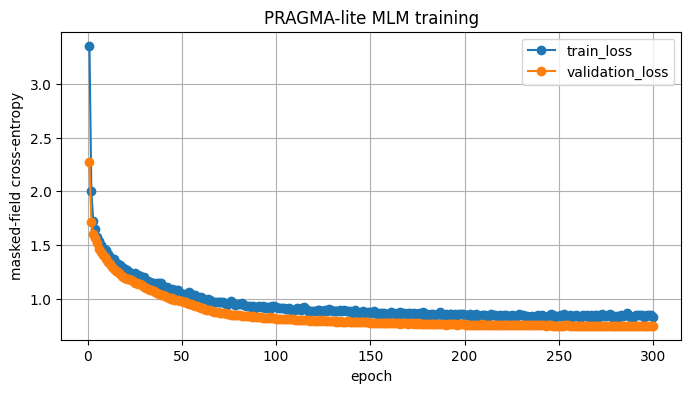

Saved artifacts:
  checkpoints/pragma_lite_mlm/best.pt
  checkpoints/pragma_lite_mlm/last.pt
  checkpoints/pragma_lite_mlm/metrics.csv
  checkpoints/pragma_lite_mlm/tokenizers/event_tokenizer_state.json
  checkpoints/pragma_lite_mlm/tokenizers/lifelong_tokenizer_state.json
  checkpoints/pragma_lite_mlm/tokenizers/profile_tokenizer_state.json


In [11]:
import matplotlib.pyplot as plt

ax = metrics.set_index('epoch')[['train_loss', 'validation_loss']].plot(
    marker='o', figsize=(8, 4), grid=True,
)
ax.set_ylabel('masked-field cross-entropy')
ax.set_title('PRAGMA-lite MLM training')
plt.show()

print('Saved artifacts:')
for path in sorted(CHECKPOINT_DIR.rglob('*')):
    if path.is_file():
        print(' ', path.relative_to(ARTIFACT_ROOT))

## Downstream transfer probe: observed loan repayment trouble

This freezes the best MLM encoder and trains only a class-balanced logistic-regression head. Each sample ends immediately **before** its loan grant date, so grant-day transactions and the `loan_granted` profile event are not inputs. The positive class is the published `B`/`D` observed problem-loan status.

This is deliberately an exploratory embedding-transfer test, not a production credit-scoring claim. The held-out test split has only eight positive examples, so inspect the bootstrap interval and do not over-interpret a single score.

In [ ]:
import json

probe_script = PROJECT_ROOT / 'demos' / 'run_loan_probe.py'
probe_metrics_path = CHECKPOINT_DIR / 'loan_probe_metrics.json'
assert (CHECKPOINT_DIR / 'best.pt').exists(), 'Train first or set RESUME_FROM to a completed run.'

!{sys.executable} {probe_script} --checkpoint {CHECKPOINT_DIR / 'best.pt'} --device {DEVICE.type}

with probe_metrics_path.open(encoding='utf-8') as handle:
    loan_probe_metrics = json.load(handle)
loan_probe_metrics

## Sensible first experiments

1. Confirm a 1-epoch GPU run completes and `best.pt` is written.
2. Increase `EPOCHS` to 20–50 only after the validation curve is stable.
3. Increase `BATCH_SIZE` gradually if GPU memory has room.
4. Keep `MAX_EVENTS=64` initially; changing it changes the effective task context.
5. Do not refit tokenizers on validation/test data or overwrite the tokenizer files attached to a checkpoint.

The next separate piece of work, once MLM behaviour is credible, is a downstream task head and a leakage-safe task-specific split.